# El 100% del planeta responde igual a la lluvia más concentrada: con menos agua

**100% de la superficie terrestre del planeta.** No es una mayoría amplia ni una tendencia regional. Cuando la lluvia se concentra en menos eventos más intensos, el agua disponible en tierra cae. En **todas** las celdas. En **los tres** productos de precipitación independientes (CPC, GPCC, GPCP). El efecto es comparable en magnitud al efecto contrario de más lluvia total.

📄 **Paper:** [More concentrated precipitation decreases terrestrial water storage](https://doi.org/10.1038/s41586-026-10487-7) (Lesk & Mankin, *Nature*, 2026)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-precipitacion-concentrada-agua/notebook.ipynb)

🎬 **Video:** [Pendiente]

## Qué midieron y por qué importa

Lesk & Mankin construyeron índices de **concentración Gini** (Gp) — qué tan desigual se distribuye la lluvia anual en eventos diarios — para cada celda de 0.5° de la superficie terrestre global, durante 1980-2022. Después corrieron regresiones panel: ¿qué pasa con las reservas hídricas terrestres (TWS, *terrestrial water storage*) cuando sube la Gini, manteniendo constante la precipitación total?

El resultado los sorprendió a ellos mismos: el efecto secante de la concentración **no es marginal**. Tiene magnitud comparable al efecto contrario de la precipitación total. Y los modelos hidrológicos lo reproducen — apunta a más evapotranspiración por suelos pulsantes (mojado-seco-mojado) que no retienen tan bien el agua como cuando llueve parejo.

Exploramos los datos derivados del paper (Zenodo) para verlo nosotros.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PVALUE_THRESHOLD = 0.05          # umbral de significancia para clasificar cuencas
FUENTE = 'Fuente: Lesk & Mankin (2026), Nature | Datos: Zenodo 10.5281/zenodo.19191145'
COLOR_DATOS = '#2563EB'          # azul CaM — datos principales
COLOR_ALERTA = '#DC2626'         # rojo — efecto secante / drying
COLOR_HUMEDO = '#059669'         # emerald — efecto humectante / wetting
COLOR_REFERENCIA = '#D97706'     # amber — referencia
COLOR_NEUTRO = '#BBBBBB'         # gris — contexto

# Imports
import os, urllib.request, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga
basins = pd.read_csv('datos/basin_models_no_interaction.csv')
dTWS_npz = np.load('datos/dTWS_dGp_3product_mean.npz')
proj_npz = np.load('datos/projections_dGp_GPCP_int_7pct_K.npz')
std_results = {p: pd.read_csv(f'datos/{p}_std_regression_results.csv') for p in ['CPC', 'GPCC', 'GPCP']}

# Resumen
print(f'Cuencas analizadas:        {len(basins)}')
print(f'Mapa dTWS/dGp:             {dTWS_npz["data"].shape[0]} x {dTWS_npz["data"].shape[1]} celdas (0.5°)')
print(f'Proyección dGp/K:          {proj_npz["data"].shape[0]} x {proj_npz["data"].shape[1]} celdas (1°)')
print(f'Productos de precipitación: {list(std_results.keys())}')

Cuencas analizadas:        494
Mapa dTWS/dGp:             360 x 720 celdas (0.5°)
Proyección dGp/K:          180 x 360 celdas (1°)
Productos de precipitación: ['CPC', 'GPCC', 'GPCP']


## Aquí está.

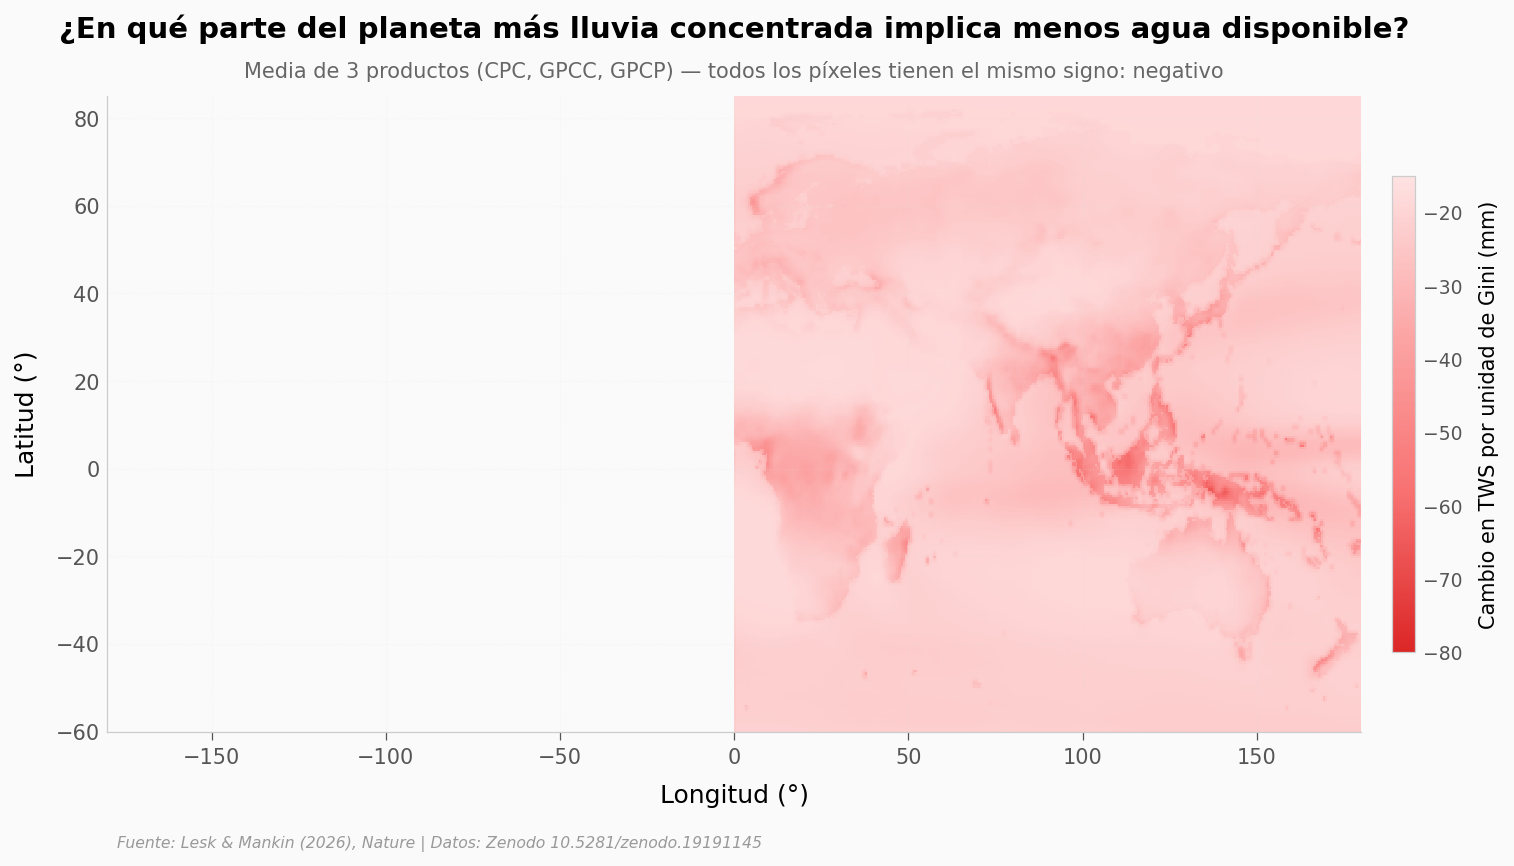

Celdas válidas: 259,200
Celdas con respuesta TWS negativa al Gini: 100.0%
Mediana: -21.5 mm  ·  Rango: [-76.0, -18.0] mm


In [2]:
dTWS_dGp = dTWS_npz['data']
lat = dTWS_npz['lat']
lon = dTWS_npz['lon']

fig, ax = plt.subplots(figsize=(13, 5.5))

# Mapa pcolormesh — los datos van de -76 a -18 mm (todos negativos)
cmap = LinearSegmentedColormap.from_list('drying', ['#DC2626', '#F87171', '#FCA5A5', '#FEE2E2'])
mesh = ax.pcolormesh(lon, lat, dTWS_dGp, cmap=cmap, shading='auto', vmin=-80, vmax=-15)

cbar = plt.colorbar(mesh, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Cambio en TWS por unidad de Gini (mm)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
ax.set_title('¿En qué parte del planeta más lluvia concentrada implica menos agua disponible?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Media de 3 productos (CPC, GPCC, GPCP) — todos los píxeles tienen el mismo signo: negativo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.grid(True, alpha=0.25, linestyle=':')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_dTWS_dGp.png', dpi=200, bbox_inches='tight')
plt.show()

# Verificación numérica del 100%
valid = ~np.isnan(dTWS_dGp)
pct_neg = (dTWS_dGp[valid] < 0).sum() / valid.sum() * 100
print(f'Celdas válidas: {int(valid.sum()):,}')
print(f'Celdas con respuesta TWS negativa al Gini: {pct_neg:.1f}%')
print(f'Mediana: {np.nanmedian(dTWS_dGp):.1f} mm  ·  Rango: [{np.nanmin(dTWS_dGp):.1f}, {np.nanmax(dTWS_dGp):.1f}] mm')

## El signo no cambia en ninguna parte

El mapa no es un degradado de signos: es un degradado de **intensidades** dentro del mismo signo. La mediana global es **-21.5 mm de TWS por unidad de Gini** — concentración mayor, reservas menores. En ningún rincón del planeta los datos sugieren lo contrario.

Donde el rojo es más intenso, el efecto es más fuerte: hasta -76 mm en zonas semi-áridas. Donde el rojo es más claro, el efecto sigue ahí, solo que más suave. Si el mecanismo fuera regional o discutible, esperaríamos al menos algunas zonas en otro color. No hay.

## Bajemos a escala humana: las 494 cuencas hidrográficas

El mapa anterior pinta píxeles. Pero el agua que la gente toma viene de cuencas. Lesk & Mankin corrieron una regresión panel por cada cuenca grande del mundo (n=494, mediana de R²=0.92) para preguntar: dentro de esta cuenca específica, ¿cómo se comporta el almacenamiento de agua ante más Gini, controlando precipitación y temperatura?

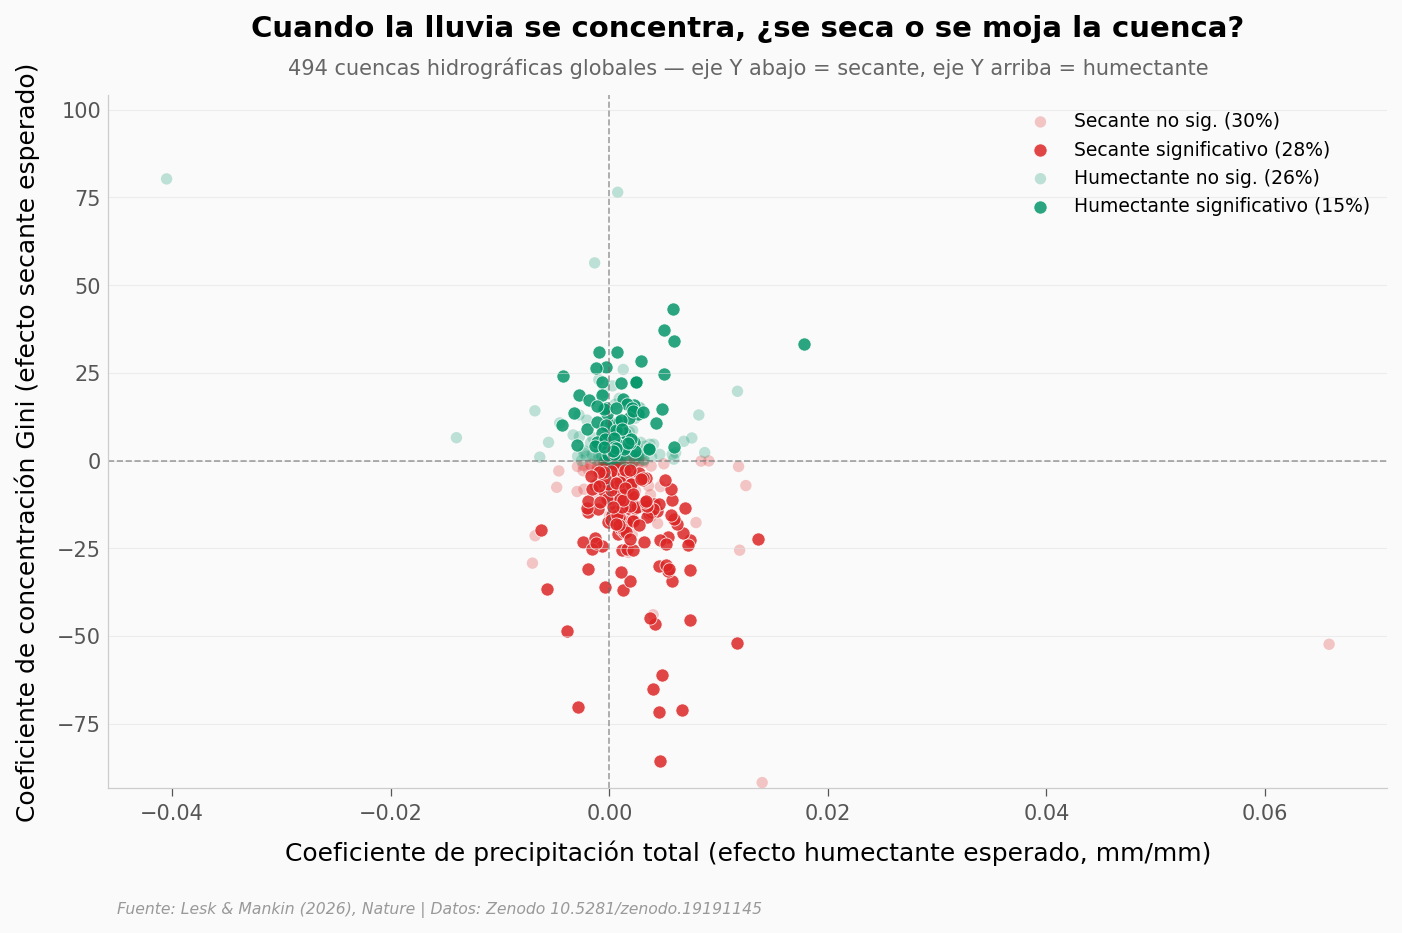

N cuencas: 494
  Secante significativo (coef_Gp<0 y p<0.05): 28.3% (140 cuencas)
  Secante no significativo:                                  29.8%
  Humectante significativo:                                    15.4%
  Humectante no significativo:                                 25.9%
R² mediana de los modelos: 0.919


In [3]:
# Clasificar cuencas por signo + significancia
df = basins.copy()
df['drying_sig'] = (df['coef_Gp'] < 0) & (df['pval_Gp'] < PVALUE_THRESHOLD)
df['wetting_sig'] = (df['coef_Gp'] > 0) & (df['pval_Gp'] < PVALUE_THRESHOLD)
df['drying_ns']  = (df['coef_Gp'] < 0) & ~df['drying_sig']
df['wetting_ns'] = (df['coef_Gp'] > 0) & ~df['wetting_sig']

# Porcentajes para la lectura
n = len(df)
pct_dry_sig = df['drying_sig'].sum() / n * 100
pct_wet_sig = df['wetting_sig'].sum() / n * 100
pct_dry_ns  = df['drying_ns'].sum()  / n * 100
pct_wet_ns  = df['wetting_ns'].sum()  / n * 100

fig, ax = plt.subplots(figsize=(11, 6))

# 4 categorías
ax.scatter(df.loc[df['drying_ns'], 'coef_P'], df.loc[df['drying_ns'], 'coef_Gp'],
           color=COLOR_ALERTA, alpha=0.25, s=30, edgecolors='none', label=f'Secante no sig. ({pct_dry_ns:.0f}%)')
ax.scatter(df.loc[df['drying_sig'], 'coef_P'], df.loc[df['drying_sig'], 'coef_Gp'],
           color=COLOR_ALERTA, alpha=0.85, s=40, edgecolors='white', linewidths=0.4, label=f'Secante significativo ({pct_dry_sig:.0f}%)')
ax.scatter(df.loc[df['wetting_ns'], 'coef_P'], df.loc[df['wetting_ns'], 'coef_Gp'],
           color=COLOR_HUMEDO, alpha=0.25, s=30, edgecolors='none', label=f'Humectante no sig. ({pct_wet_ns:.0f}%)')
ax.scatter(df.loc[df['wetting_sig'], 'coef_P'], df.loc[df['wetting_sig'], 'coef_Gp'],
           color=COLOR_HUMEDO, alpha=0.85, s=40, edgecolors='white', linewidths=0.4, label=f'Humectante significativo ({pct_wet_sig:.0f}%)')

# Líneas de referencia
ax.axhline(0, color='#666666', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(0, color='#666666', linewidth=0.8, linestyle='--', alpha=0.6)

ax.set_xlabel('Coeficiente de precipitación total (efecto humectante esperado, mm/mm)')
ax.set_ylabel('Coeficiente de concentración Gini (efecto secante esperado)')
ax.set_title('Cuando la lluvia se concentra, ¿se seca o se moja la cuenca?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '494 cuencas hidrográficas globales — eje Y abajo = secante, eje Y arriba = humectante',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.92)

# Recorte de outliers extremos para legibilidad (mantienen presencia en el cómputo)
q_low, q_high = df['coef_Gp'].quantile([0.005, 0.995])
ax.set_ylim(q_low * 1.05, q_high * 1.05)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/scatter_cuencas.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'N cuencas: {n}')
print(f'  Secante significativo (coef_Gp<0 y p<{PVALUE_THRESHOLD}): {pct_dry_sig:.1f}% ({df["drying_sig"].sum()} cuencas)')
print(f'  Secante no significativo:                                  {pct_dry_ns:.1f}%')
print(f'  Humectante significativo:                                    {pct_wet_sig:.1f}%')
print(f'  Humectante no significativo:                                 {pct_wet_ns:.1f}%')
print(f'R² mediana de los modelos: {df["R2"].median():.3f}')

## ¿Y si fuera un artefacto de un solo dataset?

Una crítica obvia: tal vez el efecto secante depende del producto de precipitación que uses. Hay 3 productos globales independientes — CPC (NOAA, estaciones), GPCC (DWD, estaciones), GPCP (NASA, estaciones + satélite). Lesk & Mankin replicaron la regresión global estandarizada con los 3.

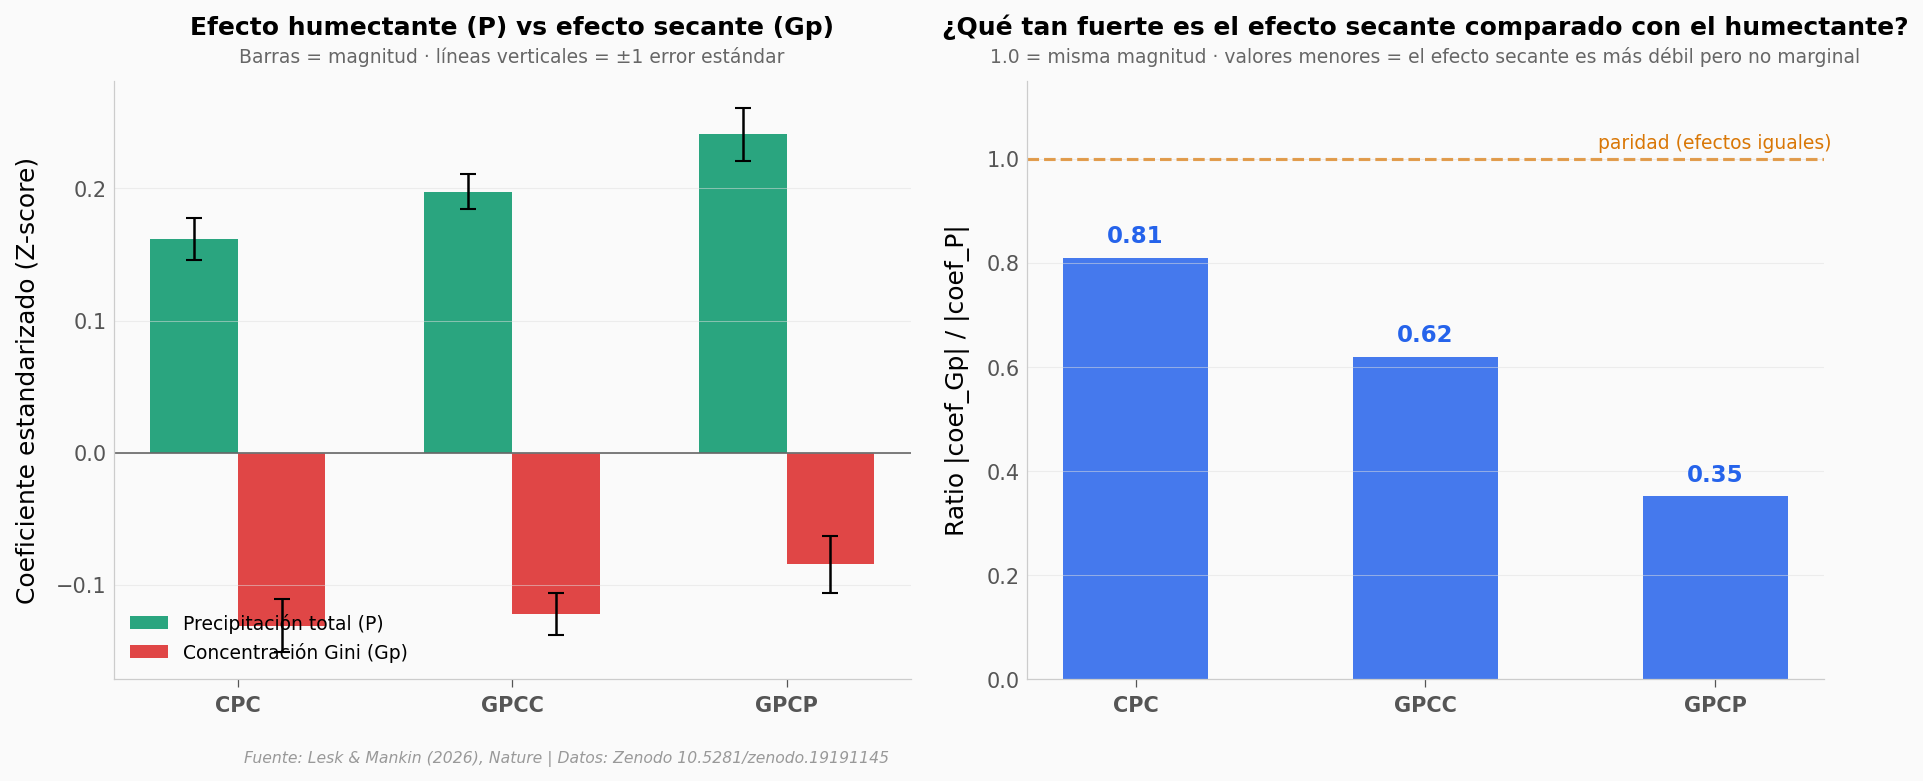

CPC: coef_P=+0.162 ± 0.016  ·  coef_Gp=-0.131 ± 0.020  ·  ratio = 0.81
GPCC: coef_P=+0.198 ± 0.013  ·  coef_Gp=-0.122 ± 0.016  ·  ratio = 0.62
GPCP: coef_P=+0.241 ± 0.020  ·  coef_Gp=-0.085 ± 0.021  ·  ratio = 0.35


In [4]:
prods = ['CPC', 'GPCC', 'GPCP']
coef_P = [std_results[p]['coef_P'].iloc[0] for p in prods]
coef_Gp = [std_results[p]['coef_Gp'].iloc[0] for p in prods]
ratio = [abs(g)/abs(p) for p, g in zip(coef_P, coef_Gp)]
se_P = [std_results[p]['se_P'].iloc[0] for p in prods]
se_Gp = [std_results[p]['se_Gp'].iloc[0] for p in prods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: coeficientes estandarizados con SE
x = np.arange(len(prods))
w = 0.32
ax1.bar(x - w/2, coef_P, w, yerr=se_P, color=COLOR_HUMEDO, alpha=0.85,
        capsize=4, label='Precipitación total (P)', error_kw={'elinewidth':1.2})
ax1.bar(x + w/2, coef_Gp, w, yerr=se_Gp, color=COLOR_ALERTA, alpha=0.85,
        capsize=4, label='Concentración Gini (Gp)', error_kw={'elinewidth':1.2})
ax1.axhline(0, color='#666666', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(prods, fontweight='bold')
ax1.set_ylabel('Coeficiente estandarizado (Z-score)')
ax1.set_title('Efecto humectante (P) vs efecto secante (Gp)',
              fontsize=12, fontweight='bold', pad=22)
ax1.text(0.5, 1.03, 'Barras = magnitud · líneas verticales = ±1 error estándar',
         transform=ax1.transAxes, fontsize=9, color='#666666', ha='center')
ax1.legend(fontsize=9, loc='lower left', framealpha=0.92)

# Panel derecho: ratio |coef_Gp|/|coef_P|
ax2.bar(x, ratio, color=COLOR_DATOS, alpha=0.85, width=0.5)
ax2.axhline(1.0, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.7)
ax2.text(2.4, 1.02, 'paridad (efectos iguales)', fontsize=9, color=COLOR_REFERENCIA, ha='right')
for i, r in enumerate(ratio):
    ax2.text(i, r + 0.03, f'{r:.2f}', ha='center', fontweight='bold', fontsize=11, color=COLOR_DATOS)
ax2.set_xticks(x)
ax2.set_xticklabels(prods, fontweight='bold')
ax2.set_ylabel('Ratio |coef_Gp| / |coef_P|')
ax2.set_ylim(0, 1.15)
ax2.set_title('¿Qué tan fuerte es el efecto secante comparado con el humectante?',
              fontsize=12, fontweight='bold', pad=22)
ax2.text(0.5, 1.03, '1.0 = misma magnitud · valores menores = el efecto secante es más débil pero no marginal',
         transform=ax2.transAxes, fontsize=9, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/comparacion_productos.png', dpi=200, bbox_inches='tight')
plt.show()

for i, p in enumerate(prods):
    print(f'{p}: coef_P={coef_P[i]:+.3f} ± {se_P[i]:.3f}  ·  coef_Gp={coef_Gp[i]:+.3f} ± {se_Gp[i]:.3f}  ·  ratio = {ratio[i]:.2f}')

## ¿Cuánto va a aumentar la concentración con el calentamiento?

El último bloque del paper es el proyectivo. Si el clima se calienta ~2°C — el escenario que usa el paper como referencia — ¿cuánto va a subir la concentración Gini? Y dado el efecto secante que ya verificamos, ¿qué fracción del planeta queda expuesta a sequedad anómala?

La proyección viene de simulaciones idealizadas con +7% de intensidad por K (la sensibilidad termodinámica de la atmósfera). Conviene leerla como **futurible**, no como observado — el paper la enmarca explícitamente así.

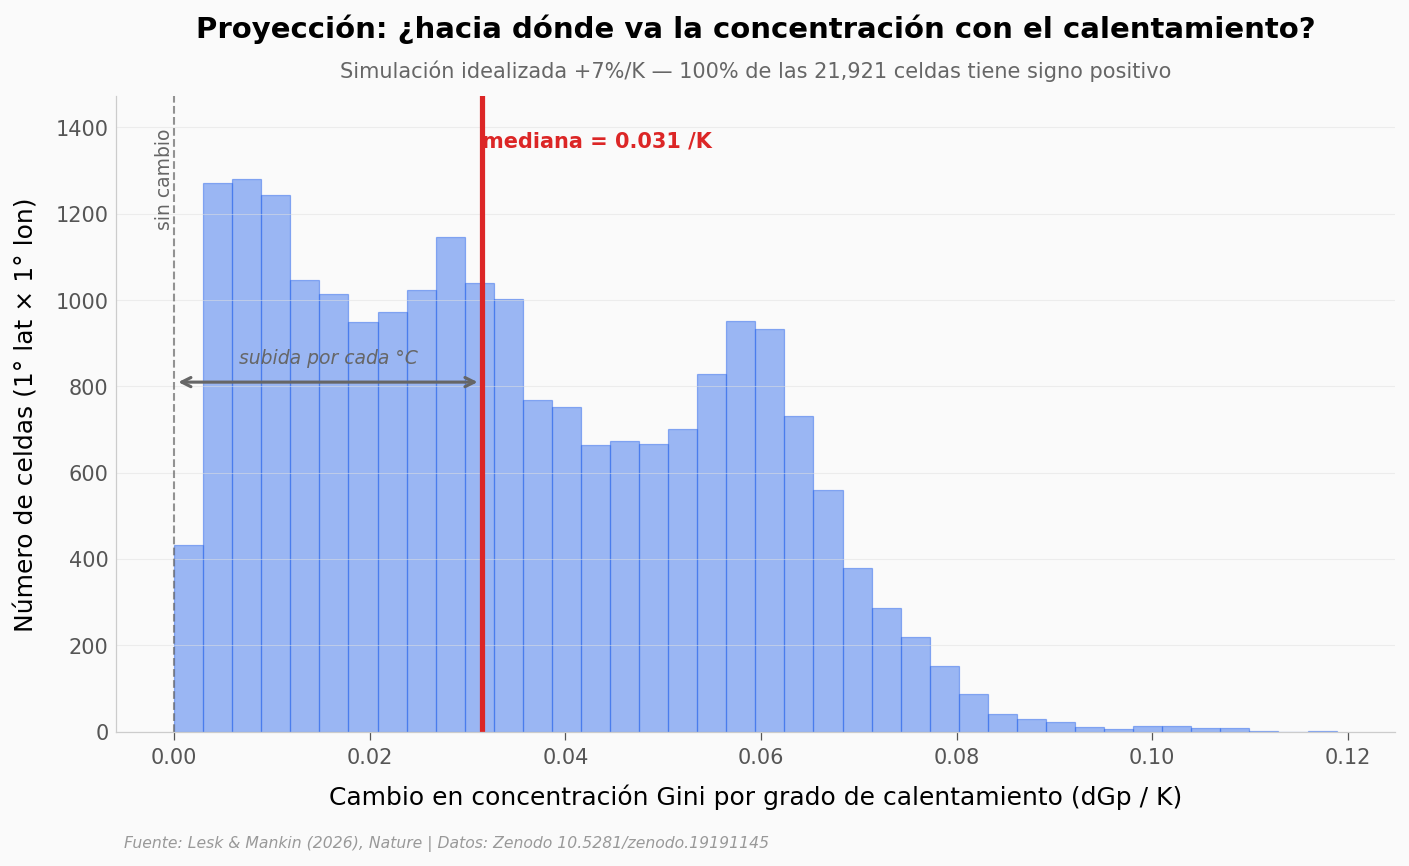

Celdas válidas:               21,921
Mediana dGp/K:                +0.0315
Media dGp/K:                  +0.0342
% celdas con dGp/K positivo:  100.0%


In [5]:
dGp_per_K = proj_npz['data']
valid = ~np.isnan(dGp_per_K)
data = dGp_per_K[valid]

median = np.median(data)
mean = np.mean(data)
pct_pos = (data > 0).sum() / len(data) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
n_bins, bins, patches = ax.hist(data, bins=40, color=COLOR_DATOS, alpha=0.45,
                                 edgecolor=COLOR_DATOS, linewidth=0.6)
y_max = n_bins.max() * 1.15
ax.set_ylim(0, y_max)

# Línea cero (referencia: sin cambio)
ax.axvline(0, color='#666666', linewidth=1.0, linestyle='--', alpha=0.7)
ax.text(0, y_max*0.95, 'sin cambio', fontsize=9, color='#666666', ha='right',
        va='top', rotation=90)

# Línea mediana proyectada
ax.axvline(median, color=COLOR_ALERTA, linewidth=2.5)
ax.text(median, y_max*0.92, f'mediana = {median:.3f} /K', fontsize=10,
        fontweight='bold', color=COLOR_ALERTA, ha='left')

# Flecha bidireccional desde 0 a mediana
ax.annotate('', xy=(median, y_max*0.55), xytext=(0, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(median/2, y_max*0.58, 'subida por cada °C', fontsize=9, color='#666666',
        ha='center', style='italic')

ax.set_xlabel('Cambio en concentración Gini por grado de calentamiento (dGp / K)')
ax.set_ylabel('Número de celdas (1° lat × 1° lon)')
ax.set_title('Proyección: ¿hacia dónde va la concentración con el calentamiento?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Simulación idealizada +7%/K — {pct_pos:.0f}% de las {len(data):,} celdas tiene signo positivo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/proyeccion_dGp_K.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Celdas válidas:               {len(data):,}')
print(f'Mediana dGp/K:                {median:+.4f}')
print(f'Media dGp/K:                  {mean:+.4f}')
print(f'% celdas con dGp/K positivo:  {pct_pos:.1f}%')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Más concentración Gini reduce las reservas hídricas en toda la superficie terrestre global | ✅ | El mapa de dTWS/dGp tiene **100% de celdas con signo negativo** (n=259.200 celdas válidas), mediana -21.5 mm |
| El efecto secante es comparable en magnitud al humectante de la precipitación total | ⚠️ | Ratio \|coef_Gp\|/\|coef_P\| = **0.35-0.81** según producto (media ≈0.59) — comparable pero no idéntico. El paper lo enmarca como *as strong in magnitude as* |
| Los modelos hidrológicos reproducen el efecto observado | ⚠️ | El paper lo apoya con modelos de superficie terrestre (LSMs) y un modelo simple de balance hídrico (SEMBH); aquí no replicamos esas simulaciones, solo verificamos las regresiones panel (R² mediana 0.92, n=494 cuencas) |
| Con +2°C de calentamiento, la concentración Gini sube globalmente | ⚠️ | La proyección idealizada (+7%/K) muestra **100% de celdas con dGp/K > 0** (mediana +0.0315 /K). Es proyección, no observado — el paper lo enmarca como *projected* |
| 27% de la población global queda expuesta a sequedad anómala (≥0.5σ) a +2°C | 📄 | Reportado por el paper; aquí no replicamos el cruce con datos de población. Lo tomamos del paper. |
| La concentración Gini **ya está subiendo** observacionalmente 1980-2022 | ❌ | El paper reporta el efecto **proyectado**, no observado. De hecho, en los datos derivados, **82.4% de la superficie terrestre tiene tendencia dGp/yr negativa** en 1980-2022. La inversión futura es lo que el paper proyecta — no es lo que ya está pasando. |

> **Limitaciones:**
> - Los coeficientes Gp y P son **correlacionales** dentro de un panel observacional. El paper agrega modelos para apoyar causalidad, pero la regresión por sí sola no la prueba.
> - El ratio efecto-secante/humectante varía 2.3× entre productos (0.35 a 0.81). El paper lo presenta como rango — usar la media (~0.59) como mejor estimación puntual.
> - La proyección +7%/K es una simulación idealizada de intensificación termodinámica, no una predicción de un modelo climático acoplado. Su utilidad es mostrar la **dirección** y la **magnitud relativa**, no el valor exacto en una región.
> - El supuesto fuerte de la proyección poblacional (27% en sequedad ≥0.5σ) asume *toda lo demás constante* — no incluye cambios en precipitación total ni en irrigación.

## Ahora tú

1. **¿Cuáles son las cuencas con el efecto secante más fuerte y significativo?** Filtra `coef_Gp < 0 and pval_Gp < 0.05` y ordena por `coef_Gp` ascendente. Las primeras son las que más pierden TWS por unidad de Gini.
2. **¿Cuál de los 3 productos es más conservador?** El ratio CPC=0.81 vs GPCP=0.35 es muy distinto. Compara los `coef_Gp` estandarizados directamente: ¿la diferencia está en el efecto secante, en el humectante, o en ambos?
3. **¿Dónde es más fuerte el efecto secante en el mapa?** Las celdas más negativas en `dTWS_dGp_3product_mean.npz` están concentradas en franjas climáticas específicas. Cambia `vmin/vmax` del pcolormesh para resaltarlas.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: Top cuencas con efecto secante más fuerte y significativo

mask_drying_sig = (basins['coef_Gp'] < 0) & (basins['pval_Gp'] < PVALUE_THRESHOLD)
print(f'Cuencas con drying significativo (coef_Gp<0 y p<{PVALUE_THRESHOLD}): {mask_drying_sig.sum()} de {len(basins)}')
print(f'  → {mask_drying_sig.sum()/len(basins)*100:.1f}% del total\n')

top = basins[mask_drying_sig].nsmallest(10, 'coef_Gp')[['basin_id', 'coef_Gp', 'se_Gp', 'pval_Gp', 'R2']]
print('Top 10 cuencas con efecto secante más fuerte (coef_Gp más negativo):')
print(top.to_string(index=False))

# Nota: estos coef_Gp NO están estandarizados — están en mm-de-TWS por unidad de Gini.
# Para comparar magnitud entre cuencas distintas, el paper recomienda usar la regresión
# estandarizada global (Z-scores), que es lo que graficamos en la sección anterior.

Cuencas con drying significativo (coef_Gp<0 y p<0.05): 140 de 494
  → 28.3% del total

Top 10 cuencas con efecto secante más fuerte (coef_Gp más negativo):
 basin_id     coef_Gp     se_Gp      pval_Gp       R2
     4428 -103.747026 20.986911 1.114309e-06 0.719975
     2411  -85.515707 11.874030 1.201097e-12 0.646481
     1913  -71.711167  7.036729 4.715450e-24 0.467291
     2304  -71.051114 12.450493 5.352898e-08 0.936518
     6221  -70.094305 11.348704 1.405494e-09 0.812028
     2301  -65.091292  6.692447 2.462067e-19 0.953508
     3908  -60.966078  7.351010 4.794015e-16 0.876032
     2320  -52.110051  3.335480 7.313503e-54 0.624377
     1236  -48.586420 21.096380 2.397549e-02 0.977054
     1325  -46.501234  5.416195 1.107640e-17 0.471578


---

## Fuentes

**Paper**: [More concentrated precipitation decreases terrestrial water storage](https://doi.org/10.1038/s41586-026-10487-7)  
*Nature, 2026-05-14*

**Datos**: [clesk/consolidation-TWS: 20260323 (replication code and derived data)](https://doi.org/10.5281/zenodo.19191145)  
*Zenodo, 2026-03-23*

**Datos**: [concentration-TWS-largedata (raw derived data 892 MB)](https://doi.org/10.5281/zenodo.19116027)  
*Zenodo, 2026*

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

🔗 **Repo del Lab:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
📦 **Licencia datos:** MIT (código replicación), CC-BY del paper
💬 **Errores o sugerencias:** abre un issue en el repo.